# Week 12: Time Series Analysis — Are REIT Returns Predictable?

**QM 2023 — Statistics II / Data Analytics**  
**Spring 2026 | University of Tulsa**

---

## What You Will Learn

By the end of this demo, you will be able to:

1. **Describe** what makes a time series different from a cross-sectional dataset — and why that changes everything about how we analyze it.
2. **Identify** whether a series is stationary or non-stationary by visual inspection and formal hypothesis testing (the Augmented Dickey-Fuller test).
3. **Interpret** autocorrelation (ACF) and partial autocorrelation (PACF) plots to understand how strongly a series depends on its own past values.
4. **Estimate** an autoregressive (AR) model on real REIT return data and select the lag order using information criteria (AIC/BIC).
5. **Run residual diagnostics** to verify that the model is well-specified.
6. **Produce and interpret** a 12-month ahead forecast with honest confidence intervals — and explain why those bands are so wide.

---

### The Big Idea

In every week so far, our observations have been **independent** of each other: one firm, one year, one row. Time series data is fundamentally different — **today depends on yesterday**. That single fact changes what models we use, what assumptions we must check, and how much we should trust our forecasts.

We will work with **38 years of monthly REIT returns** — a real, messy financial time series. By the end, you'll understand why even sophisticated hedge funds struggle to predict next month's REIT return, and exactly what statistics says about that claim.

---

## Section 1: Setup and Data Loading

We start with the same toolkit as every week. One new package today: `statsmodels` provides dedicated time series tools including the ADF test, ACF/PACF plots, and AR model estimation.

**Run this cell first.** All subsequent cells depend on these imports.

In [1]:
# =============================================================================
# ALL IMPORTS — Run this cell first
# =============================================================================
import pandas as pd                              # DataFrames — loading, filtering, date parsing
import numpy as np                               # Numerical operations — arrays, random draws
import matplotlib.pyplot as plt                  # All charts
import matplotlib.dates as mdates               # Date formatting on x-axis
from pathlib import Path                         # File paths that work on Windows and Mac

# Statsmodels time series tools
import statsmodels.api as sm                                    # General statsmodels API
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf   # ACF and PACF plots
from statsmodels.tsa.stattools import adfuller                  # Augmented Dickey-Fuller test
from statsmodels.tsa.ar_model import AutoReg                    # Autoregressive model
from statsmodels.stats.diagnostic import acorr_ljungbox         # Ljung-Box test for residuals

# Inline figures
%matplotlib inline

# Figure style — consistent look for all plots
plt.rcParams["figure.dpi"]  = 100
plt.rcParams["font.size"]   = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# =============================================================================
# COLOR PALETTE — Consistent colors used throughout the notebook
# =============================================================================
COLOR_RETURNS   = "steelblue"      # REIT monthly returns
COLOR_PRICE     = "darkgreen"      # Cumulative price index
COLOR_FORECAST  = "tomato"         # Forecast line
COLOR_CI        = "lightsalmon"    # Confidence interval shading
COLOR_RESIDUAL  = "mediumpurple"   # Residuals
COLOR_MOMENTUM  = "goldenrod"      # Momentum factor (Section 10)
COLOR_STATIONARY   = "steelblue"   # Stationary simulation
COLOR_RANDOM_WALK  = "tomato"      # Random walk simulation
COLOR_WHITENOISE   = "seagreen"    # White noise simulation
COLOR_DRIFT        = "darkorange"  # Random walk with drift simulation

# Output path — save all figures to the same folder as this notebook
DEMOS_DIR = Path(".")

print("Imports complete. Ready to go!")
print()
print("Color scheme for this notebook:")
print("  Blue  (steelblue)    = REIT returns")
print("  Green (darkgreen)    = Cumulative price index")
print("  Red   (tomato)       = Forecast line")
print("  Gold  (goldenrod)    = Momentum factor comparison")

Imports complete. Ready to go!

Color scheme for this notebook:
  Blue  (steelblue)    = REIT returns
  Green (darkgreen)    = Cumulative price index
  Red   (tomato)       = Forecast line
  Gold  (goldenrod)    = Momentum factor comparison


### Load the REIT Factor Data

Our dataset is `factors_master_long_only.csv` — 470 monthly observations covering **December 1986 through January 2026**.  
Each row is one month. The primary variable we care about is:

| Variable | Description |
|----------|-------------|
| `vwtret` | **Value-weighted REIT return** (%) — the average monthly return across all REITs, weighted by market capitalization |
| `ewtret` | Equal-weighted REIT return (%) |
| `mom_long` | Momentum factor return (%) — we use this in Section 10 for comparison |
| `date`   | Integer in YYYYMM format (e.g., `198612` = December 1986) |

> **Note on the date column:** It is stored as an integer like `198612`. We parse it with `pd.to_datetime(df['date'].astype(str), format='%Y%m')` to get proper timestamps.

In [2]:
# =============================================================================
# LOAD DATA
# =============================================================================

# Path: from demos/ go up 4 levels to repo root, then into Data/
data_path = Path("data/factors_master_long_only.csv")

df_factors_raw = pd.read_csv(data_path)

print(f"Raw data shape: {df_factors_raw.shape}  ({df_factors_raw.shape[0]} months × {df_factors_raw.shape[1]} columns)")
print(f"Columns: {df_factors_raw.columns.tolist()}")
print()
print(df_factors_raw.head(5).to_string())

Raw data shape: (470, 11)  (470 months × 11 columns)
Columns: ['date', 'ewtret', 'vwtret', 'size_long', 'value_long', 'value_reit_long', 'mom_long', 'qual_long', 'qual_reit_long', 'lowvol_long', 'rev_long']

     date    ewtret    vwtret  size_long  value_long  value_reit_long  mom_long  qual_long  qual_reit_long  lowvol_long  rev_long
0  198612  3.620926  2.155515  15.255863    0.410868              NaN  2.881204   4.962157        2.681146     2.259393  1.350317
1  198701  1.992818  3.219624  -2.085253   -0.155328              NaN  1.639060   1.157903        3.473944     1.669151  1.765375
2  198702  0.511081  0.237099  -0.439769    6.147062              NaN  0.075723  -3.124757       -3.616169    -1.797324  5.029760
3  198703 -2.580357 -2.757591  -0.804238    2.568383              NaN -2.653485   1.703312       -3.283527     0.360070 -3.677231
4  198704 -0.767544 -1.071044  -2.643715   -1.643585              NaN  0.153750  -0.907825        0.357461     0.414239  2.355774


In [3]:
# =============================================================================
# DATE PARSING AND INDEXING
# =============================================================================

# The 'date' column is an integer like 198612 (= December 1986)
# We convert it to a proper Timestamp so we can plot and index by date
df_factors = df_factors_raw.copy()
df_factors["date"] = pd.to_datetime(df_factors["date"].astype(str), format="%Y%m")

# Set the date as the index — required for most statsmodels time series functions
df_factors = df_factors.set_index("date").sort_index()

# The last 14 rows have NaN for all return columns (placeholder rows for future dates)
# Drop rows where vwtret is missing — we can only analyze months with actual data
df_factors = df_factors.dropna(subset=["vwtret"])

# Extract our main series as an explicit named variable
vwtret_series = df_factors["vwtret"]   # Value-weighted REIT monthly return (%)

print(f"After dropping NaN rows: {len(df_factors)} monthly observations")
print(f"Date range: {df_factors.index.min().strftime('%B %Y')} to {df_factors.index.max().strftime('%B %Y')}")
print()
print("Summary statistics for vwtret (value-weighted REIT return, %):")
print(vwtret_series.describe().round(3))

After dropping NaN rows: 456 monthly observations
Date range: December 1986 to November 2024

Summary statistics for vwtret (value-weighted REIT return, %):
count    456.000
mean       0.807
std        5.077
min      -30.212
25%       -1.720
50%        1.094
75%        3.598
max       27.881
Name: vwtret, dtype: float64


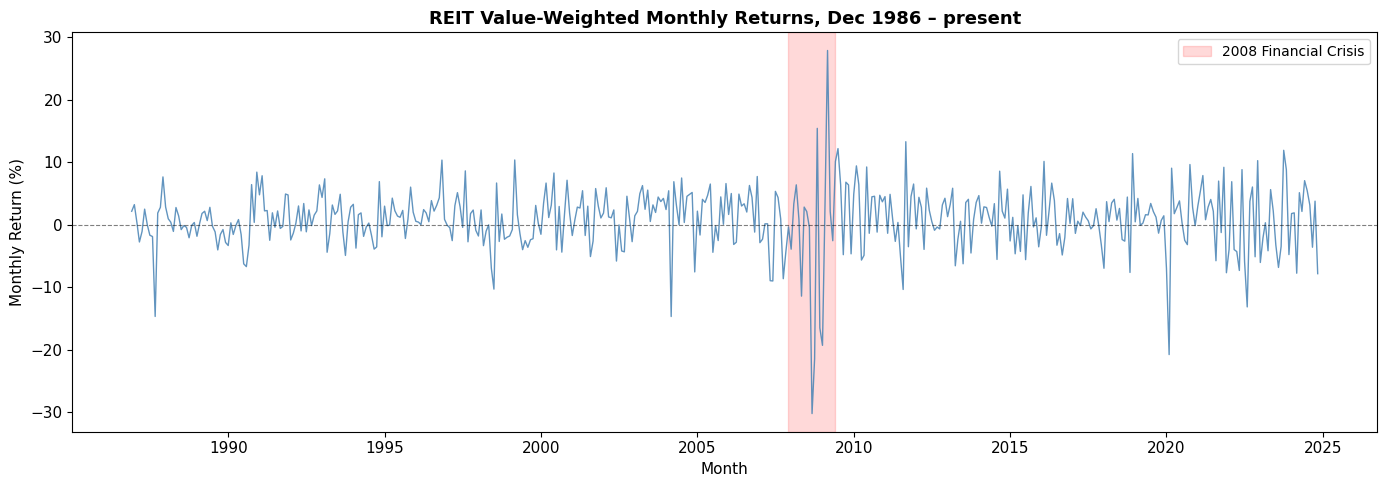

Chart saved: fig01_returns_history.png
Largest single-month gain:  27.88% in Mar 2009
Largest single-month loss:  -30.21% in Sep 2008


In [4]:
# =============================================================================
# CHART 1 — Full history of REIT value-weighted returns
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 5))

# Plot the return series
ax.plot(vwtret_series.index, vwtret_series.values,
        color=COLOR_RETURNS, linewidth=1.0, alpha=0.85)

# Shade the 2008 financial crisis for context
crisis_start = pd.Timestamp("2007-12-01")
crisis_end   = pd.Timestamp("2009-06-01")
ax.axvspan(crisis_start, crisis_end, alpha=0.15, color="red", label="2008 Financial Crisis")

# Add a horizontal zero line
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

ax.set_title("REIT Value-Weighted Monthly Returns, Dec 1986 – present", fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly Return (%)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(DEMOS_DIR / "fig01_returns_history.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Chart saved: fig01_returns_history.png")
print(f"Largest single-month gain:  {vwtret_series.max():.2f}% in {vwtret_series.idxmax().strftime('%b %Y')}")
print(f"Largest single-month loss:  {vwtret_series.min():.2f}% in {vwtret_series.idxmin().strftime('%b %Y')}")

---

## Section 2: What Is a Time Series? — Visual Introduction

A **time series** is just a sequence of values measured at regular intervals over time. What makes it special — and tricky — is that observations are **not independent**. Today's REIT return is (at least a little) correlated with last month's return.

The first thing we always do with time series data is plot **two versions** of the same underlying data:

- **The return series** — shows month-to-month changes. Bounces up and down around zero.
- **The price index** — shows cumulative growth. Trends upward over long horizons.

These two views emphasize something profound: the *same data* can look stationary or non-stationary depending on how you measure it. That distinction is the foundation of everything we will do today.

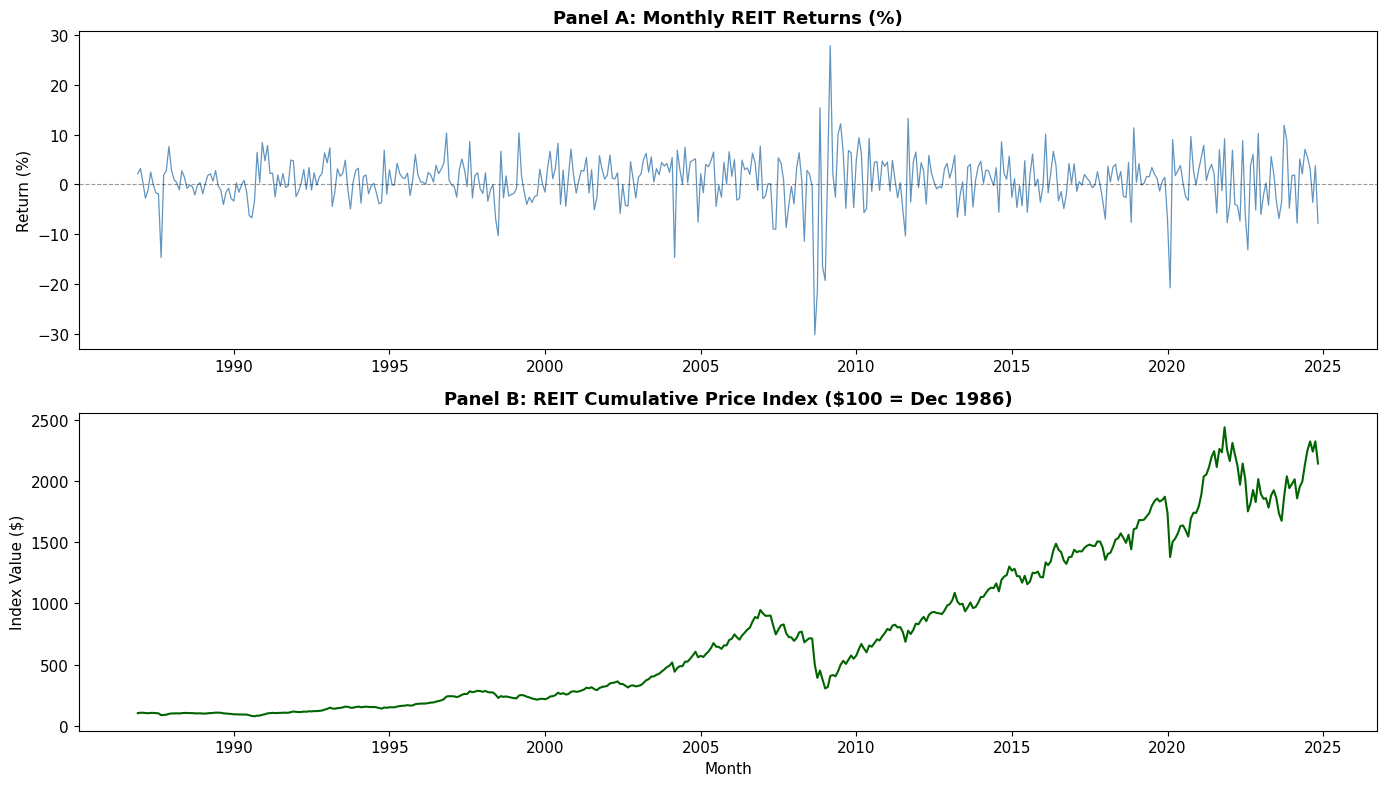

Chart saved: fig02_returns_vs_price_index.png

$100 invested in Dec 1986 grew to $2144 — a 21.0x increase.


In [5]:
# =============================================================================
# CHART 2 — Return series vs. cumulative price index (2-panel)
# =============================================================================

# Compute the price index: start at $1.00 in Dec 1986 and compound each month
# (1 + 0.02155) means a 2.155% gain that month multiplied into the running total
reit_price_index = (1 + vwtret_series / 100).cumprod()   # Divide by 100 because returns are in %
reit_price_index = reit_price_index * 100                 # Rescale: start at $100 for readability

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# --- Top panel: monthly returns ---
ax = axes[0]
ax.plot(vwtret_series.index, vwtret_series.values, color=COLOR_RETURNS, linewidth=0.9, alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_title("Panel A: Monthly REIT Returns (%)", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Return (%)")

# --- Bottom panel: cumulative price index ---
ax = axes[1]
ax.plot(reit_price_index.index, reit_price_index.values, color=COLOR_PRICE, linewidth=1.5)
ax.set_title("Panel B: REIT Cumulative Price Index ($100 = Dec 1986)", fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Index Value ($)")

plt.tight_layout()
plt.savefig(DEMOS_DIR / "fig02_returns_vs_price_index.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: fig02_returns_vs_price_index.png")

# Compute total cumulative return for a quick fact
total_return_multiplier = reit_price_index.iloc[-1] / reit_price_index.iloc[0]
print(f"\n$100 invested in Dec 1986 grew to ${reit_price_index.iloc[-1]:.0f} — a {total_return_multiplier:.1f}x increase.")

### Interpretation Checkpoint

> **Why does the price index trend upward while returns bounce around zero?**

The price index is the *cumulative product* of all past returns. Because REITs have a positive average monthly return (+0.8% per month historically), small gains compound into large long-run growth.

But notice: the **level** of the price index keeps climbing. If you asked "what will next month's price be?", the best guess is "close to today's price" — and *how close* depends on how far out you're forecasting. This is the hallmark of a **random walk** (non-stationary series): there is no gravitational pull back to a fixed mean.

Returns, on the other hand, do bounce around a roughly stable mean of about +0.8%. This looks much more stationary. We will confirm that mathematically in Sections 4–5.

**Key insight:** In time series analysis, we almost always work with **returns** (or differences), not price levels. This is not just tradition — it is statistically necessary.

---

## Section 3: Stationarity — The Core Concept

**Stationarity** is the single most important concept in time series analysis.

A time series is **stationary** if its statistical properties do not change over time:

- Its **mean** stays constant (not drifting up or down)
- Its **variance** stays constant (not getting more or less volatile)
- Its **autocorrelation structure** stays constant (the same lag-1 correlation in 1990 as in 2020)

**Why does this matter?** Almost all time series models (AR, ARMA, regression with lagged variables) assume stationarity. If your series is non-stationary, your results will be unreliable — sometimes wildly so.

**Intuition:** A stationary series has no "memory" of where it started. It wanders around a fixed mean, pulled back by its own dynamics. A non-stationary series (like a random walk) can drift arbitrarily far from its starting point with no restoring force.

### LaTeX formulas

**Stationary AR(1):** $r_t = \phi \cdot r_{t-1} + \varepsilon_t$ where $|\phi| < 1$

**Random walk (non-stationary):** $P_t = P_{t-1} + \varepsilon_t$ (same formula with $\phi = 1$)

The only difference is whether $\phi$ is less than 1 or exactly equal to 1 — but the consequences are enormous.

Let's visualize the difference with **four simulated series** so you can see the pattern before we apply it to real data.

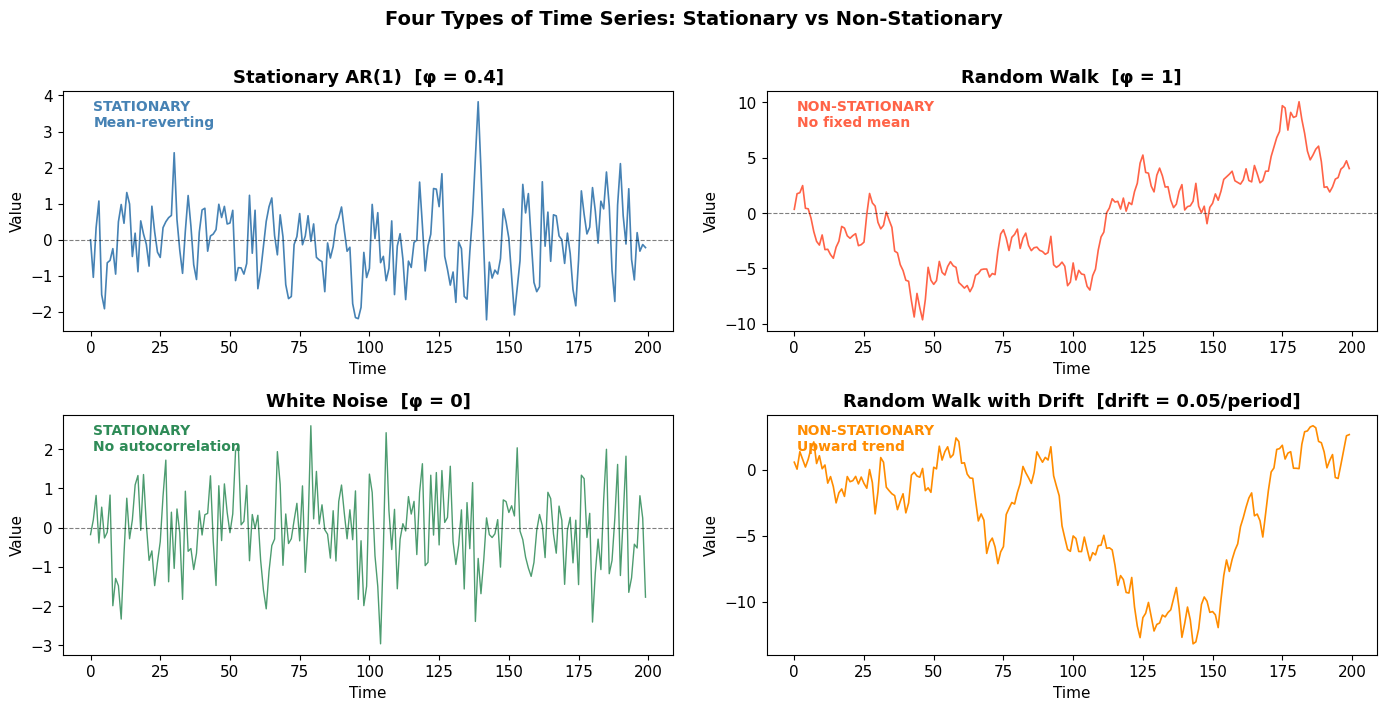

Chart saved: fig03_stationarity_examples.png


In [6]:
# =============================================================================
# CHART 3 — Four simulated series: see stationarity vs non-stationarity
# =============================================================================
# We use a fixed random seed so the charts look the same every time you run them
rng = np.random.default_rng(seed=42)

n_obs = 200   # Number of simulated time points

# --- Series 1: Stationary AR(1) with phi = 0.4 ---
# Each value = 0.4 × last value + random shock
# Because phi < 1, the series is pulled back toward zero
phi_stationary = 0.4
shocks_ar1 = rng.normal(0, 1, n_obs)
series_stationary = np.zeros(n_obs)
for t in range(1, n_obs):
    series_stationary[t] = phi_stationary * series_stationary[t - 1] + shocks_ar1[t]

# --- Series 2: Random walk (unit root, phi = 1) ---
# Each value = last value + random shock
# No restoring force → series wanders with no fixed mean
shocks_rw = rng.normal(0, 1, n_obs)
series_random_walk = np.cumsum(shocks_rw)   # Cumulative sum = random walk

# --- Series 3: White noise (phi = 0) ---
# Each value is a completely independent random draw — the simplest stationary series
series_white_noise = rng.normal(0, 1, n_obs)

# --- Series 4: Random walk with drift ---
# Like a random walk, but with a positive trend added each period
drift_per_period = 0.05
shocks_drift = rng.normal(0, 1, n_obs)
series_drift = np.cumsum(shocks_drift + drift_per_period)

# --- Plot all four series ---
time_axis = np.arange(n_obs)

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

# Top-left: Stationary AR(1)
axes[0, 0].plot(time_axis, series_stationary, color=COLOR_STATIONARY, linewidth=1.2)
axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
axes[0, 0].set_title("Stationary AR(1)  [φ = 0.4]", fontweight="bold")
axes[0, 0].set_ylabel("Value")
axes[0, 0].set_xlabel("Time")
axes[0, 0].annotate("STATIONARY\nMean-reverting", xy=(0.05, 0.85),
                    xycoords="axes fraction", fontsize=10, color=COLOR_STATIONARY,
                    fontweight="bold")

# Top-right: Random walk
axes[0, 1].plot(time_axis, series_random_walk, color=COLOR_RANDOM_WALK, linewidth=1.2)
axes[0, 1].axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
axes[0, 1].set_title("Random Walk  [φ = 1]", fontweight="bold")
axes[0, 1].set_ylabel("Value")
axes[0, 1].set_xlabel("Time")
axes[0, 1].annotate("NON-STATIONARY\nNo fixed mean", xy=(0.05, 0.85),
                    xycoords="axes fraction", fontsize=10, color=COLOR_RANDOM_WALK,
                    fontweight="bold")

# Bottom-left: White noise
axes[1, 0].plot(time_axis, series_white_noise, color=COLOR_WHITENOISE, linewidth=1.0, alpha=0.85)
axes[1, 0].axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
axes[1, 0].set_title("White Noise  [φ = 0]", fontweight="bold")
axes[1, 0].set_ylabel("Value")
axes[1, 0].set_xlabel("Time")
axes[1, 0].annotate("STATIONARY\nNo autocorrelation", xy=(0.05, 0.85),
                    xycoords="axes fraction", fontsize=10, color=COLOR_WHITENOISE,
                    fontweight="bold")

# Bottom-right: Random walk with drift
axes[1, 1].plot(time_axis, series_drift, color=COLOR_DRIFT, linewidth=1.2)
axes[1, 1].set_title("Random Walk with Drift  [drift = 0.05/period]", fontweight="bold")
axes[1, 1].set_ylabel("Value")
axes[1, 1].set_xlabel("Time")
axes[1, 1].annotate("NON-STATIONARY\nUpward trend", xy=(0.05, 0.85),
                    xycoords="axes fraction", fontsize=10, color=COLOR_DRIFT,
                    fontweight="bold")

fig.suptitle("Four Types of Time Series: Stationary vs Non-Stationary",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(DEMOS_DIR / "fig03_stationarity_examples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: fig03_stationarity_examples.png")

### Interpretation Checkpoint

> **Which of these simulated series looks like REIT monthly returns? Which looks like the REIT price index?**

- **REIT monthly returns** look like the **stationary AR(1)** (top-left): they bounce around a roughly stable mean, occasionally spiking but then returning.
- **REIT price index** looks like the **random walk with drift** (bottom-right): it wanders upward with no anchor.

**The core lesson:** When working with financial data, always ask: *am I looking at prices or returns?* Prices are almost always non-stationary. Returns are often (approximately) stationary.

---

## Section 4: Autocorrelation Functions (ACF and PACF)

Before fitting any model, we need to understand **how much a series correlates with its own past**. Two standard diagnostic plots help with this:

### ACF — Autocorrelation Function
The ACF at lag $k$ answers: *"If I know the value today, how predictive is that for the value $k$ periods from now?"*

$$\rho_k = \text{Corr}(r_t,\; r_{t-k})$$

If $\rho_1 = 0.2$, that means today's return and last month's return have a correlation of 0.20.

### PACF — Partial Autocorrelation Function
The PACF at lag $k$ answers: *"How much direct predictive power does the value $k$ periods ago have, after removing the influence of all lags in between?"*

The PACF is the key tool for choosing the lag order $p$ in an AR($p$) model — the first lag where PACF drops inside the confidence bands tells you roughly what $p$ should be.

### The Blue Confidence Bands
The shaded (or dashed) blue lines mark approximate 95% confidence intervals under the null hypothesis that **the true autocorrelation is zero**. Bars that extend outside the blue bands are **statistically significant** — the series has genuine autocorrelation at that lag.

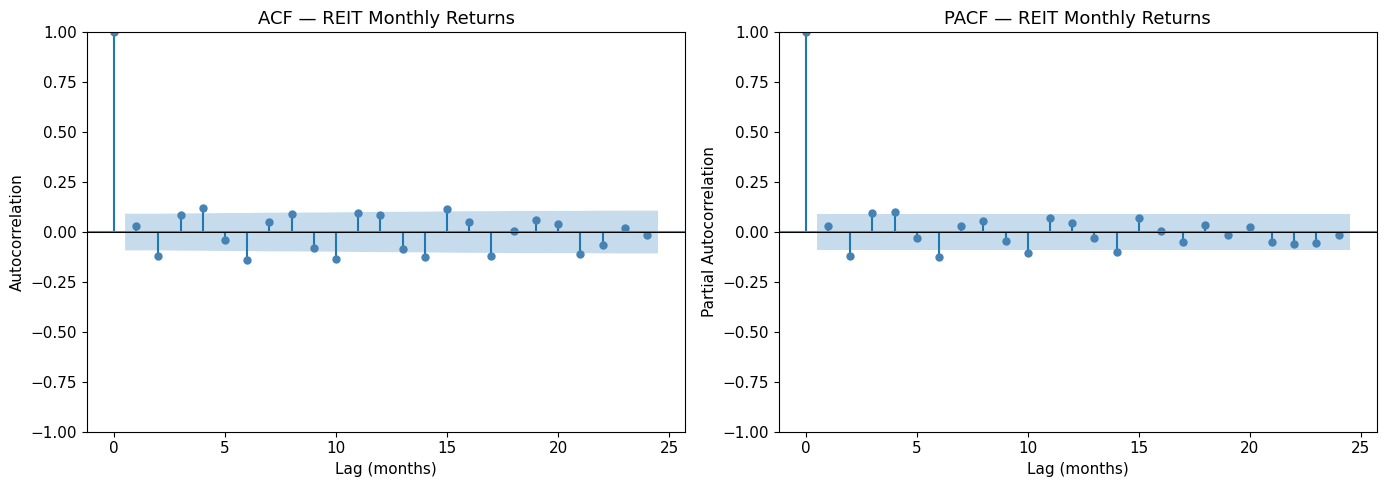

Chart saved: fig04_acf_pacf_returns.png

ACF values at first 6 lags:
  Lag 1: +0.0296
  Lag 2: -0.1187
  Lag 3: +0.0854
  Lag 4: +0.1194
  Lag 5: -0.0396
  Lag 6: -0.1409


In [7]:
# =============================================================================
# CHART 4 — ACF and PACF of REIT monthly returns
# =============================================================================

# Re-define vwtret_series here so this cell runs independently
vwtret_series = df_factors["vwtret"]   # Value-weighted REIT monthly return (%)

n_lags_to_show = 24   # 2 years of monthly lags

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left panel: ACF ---
plot_acf(
    vwtret_series,
    lags=n_lags_to_show,
    ax=axes[0],
    color=COLOR_RETURNS,
    alpha=0.05,          # 95% confidence bands
    title="ACF — REIT Monthly Returns"
)
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Autocorrelation")
axes[0].axhline(0, color="black", linewidth=0.7)

# --- Right panel: PACF ---
plot_pacf(
    vwtret_series,
    lags=n_lags_to_show,
    ax=axes[1],
    method="ywm",        # Yule-Walker modified (recommended for small samples)
    color=COLOR_RETURNS,
    alpha=0.05,
    title="PACF — REIT Monthly Returns"
)
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Partial Autocorrelation")
axes[1].axhline(0, color="black", linewidth=0.7)

plt.tight_layout()
plt.savefig(DEMOS_DIR / "fig04_acf_pacf_returns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: fig04_acf_pacf_returns.png")

# Print the raw ACF values at the first few lags
from statsmodels.tsa.stattools import acf
acf_values = acf(vwtret_series, nlags=6, fft=True)
print("\nACF values at first 6 lags:")
for lag_num in range(1, 7):
    print(f"  Lag {lag_num}: {acf_values[lag_num]:+.4f}")

### Interpretation Checkpoint

> **Do you see significant autocorrelation at any lag? What does that suggest about the AR order?**

Look at your ACF and PACF plots and check:

- **Lag 1:** Is it outside the blue confidence bands? A small positive lag-1 autocorrelation in REIT returns is well-documented — it comes from **appraisal smoothing** (commercial real estate appraisals are slow to update, creating artificial persistence).
- **Lags 2–24:** Do any stand out, or do they mostly stay within the bands?
- **PACF:** If only lag 1 is significant in the PACF and higher lags are not, that suggests an **AR(1) model** is appropriate.

**Financial economics context:** REIT returns have weaker autocorrelation than individual commercial properties (which are extremely illiquid and slow to reprice). But they have slightly stronger autocorrelation than large-cap stocks, because their underlying asset prices (buildings, land) update slowly.

---

## Section 5: The Augmented Dickey-Fuller (ADF) Test

We just *looked* at stationarity visually. Now let's test for it formally.

The **Augmented Dickey-Fuller (ADF) test** is the standard test for a unit root (non-stationarity):

$$H_0:\; \text{The series has a unit root (is non-stationary)}$$
$$H_1:\; \text{The series is stationary (no unit root)}$$

If the test statistic is **more negative than the critical value** (or equivalently, p-value < 0.05), we **reject H₀** and conclude the series is stationary.

**Important:** This is one of the few tests where more negative = stronger evidence. Think of it as a "pull to the mean" score — the more negative, the stronger the gravitational pull.

We will run the ADF on two series:

1. **REIT monthly returns** (`vwtret_series`) — we expect this to be stationary
2. **REIT price index** (`reit_price_index`) — we expect this to be non-stationary

Putting them side by side makes the contrast stark and memorable.

In [8]:
# =============================================================================
# ADF TEST — Returns (expect: stationary, reject H0)
# =============================================================================

# Re-define vwtret_series and reit_price_index (so this cell runs independently)
vwtret_series    = df_factors["vwtret"]
reit_price_index = (1 + vwtret_series / 100).cumprod() * 100

# Run ADF on returns
adf_result_returns = adfuller(vwtret_series, autolag="AIC")
adf_stat_returns   = adf_result_returns[0]   # Test statistic
adf_pval_returns   = adf_result_returns[1]   # p-value
adf_crit_returns   = adf_result_returns[4]   # Dict of critical values

print("=" * 60)
print("ADF TEST: REIT Monthly Returns (vwtret)")
print("=" * 60)
print(f"Test statistic:  {adf_stat_returns:.4f}")
print(f"p-value:         {adf_pval_returns:.6f}")
print(f"Critical values:")
for level, cval in adf_crit_returns.items():
    print(f"   {level}: {cval:.4f}")
print()
if adf_pval_returns < 0.05:
    print("CONCLUSION: p < 0.05 → Reject H0 → SERIES IS STATIONARY")
else:
    print("CONCLUSION: p ≥ 0.05 → Fail to reject H0 → SERIES MAY BE NON-STATIONARY")

ADF TEST: REIT Monthly Returns (vwtret)
Test statistic:  -9.1597
p-value:         0.000000
Critical values:
   1%: -3.4450
   5%: -2.8680
   10%: -2.5702

CONCLUSION: p < 0.05 → Reject H0 → SERIES IS STATIONARY


In [9]:
# =============================================================================
# ADF TEST — Price Index (expect: non-stationary, fail to reject H0)
# =============================================================================

adf_result_price = adfuller(reit_price_index, autolag="AIC")
adf_stat_price   = adf_result_price[0]
adf_pval_price   = adf_result_price[1]
adf_crit_price   = adf_result_price[4]

print("=" * 60)
print("ADF TEST: REIT Cumulative Price Index")
print("=" * 60)
print(f"Test statistic:  {adf_stat_price:.4f}")
print(f"p-value:         {adf_pval_price:.6f}")
print(f"Critical values:")
for level, cval in adf_crit_price.items():
    print(f"   {level}: {cval:.4f}")
print()
if adf_pval_price < 0.05:
    print("CONCLUSION: p < 0.05 → Reject H0 → SERIES IS STATIONARY")
else:
    print("CONCLUSION: p ≥ 0.05 → Fail to reject H0 → SERIES IS NON-STATIONARY (unit root)")

print()
print("=" * 60)
print("SIDE-BY-SIDE SUMMARY")
print("=" * 60)
print(f"{'Series':<28} {'ADF stat':>10} {'p-value':>12} {'Stationary?':>14}")
print("-" * 68)
returns_verdict = "YES" if adf_pval_returns < 0.05 else "NO"
price_verdict   = "YES" if adf_pval_price   < 0.05 else "NO"
print(f"{'REIT monthly returns':<28} {adf_stat_returns:>10.4f} {adf_pval_returns:>12.6f} {returns_verdict:>14}")
print(f"{'REIT price index':<28} {adf_stat_price:>10.4f} {adf_pval_price:>12.6f} {price_verdict:>14}")

ADF TEST: REIT Cumulative Price Index
Test statistic:  0.9414
p-value:         0.993607
Critical values:
   1%: -3.4453
   5%: -2.8681
   10%: -2.5703

CONCLUSION: p ≥ 0.05 → Fail to reject H0 → SERIES IS NON-STATIONARY (unit root)

SIDE-BY-SIDE SUMMARY
Series                         ADF stat      p-value    Stationary?
--------------------------------------------------------------------
REIT monthly returns            -9.1597     0.000000            YES
REIT price index                 0.9414     0.993607             NO


### Interpretation Checkpoint

> **Why does the ADF test behave so differently for returns vs. the price level?**

- **Returns:** The test statistic is very negative (say, around −10 or lower). The p-value is essentially zero. This means there is overwhelming evidence that returns are stationary — they are strongly mean-reverting.

- **Price index:** The test statistic is close to zero (much less negative). The p-value is large (often > 0.5). We cannot reject the null of a unit root. The price level wanders — it has no fixed mean to return to.

This is why almost every empirical finance paper works with **returns** (or log-returns) rather than price levels. It is not just convention — it is a statistical necessity.

---

## Section 6: AR Model Selection and Estimation

Now that we have confirmed `vwtret_series` is stationary, we can fit a model to it.

The simplest time series model is the **Autoregressive model of order p**, written AR($p$):

$$r_t = \mu + \phi_1 r_{t-1} + \phi_2 r_{t-2} + \cdots + \phi_p r_{t-p} + \varepsilon_t$$

- $r_t$ is this month's return
- $\phi_1, \phi_2, \ldots, \phi_p$ are the autoregressive coefficients (how much past returns predict the present)
- $\varepsilon_t$ is the unpredictable error term (white noise)

### How do we choose $p$?

1. **Visual inspection of PACF:** significant spikes at lag $k$ suggest including lag $k$
2. **Information criteria:** fit several models and compare AIC or BIC — lower is better
   - **AIC** (Akaike) penalizes complexity less → tends to prefer slightly larger models
   - **BIC** (Bayesian) penalizes complexity more → tends to prefer simpler models

We will fit AR(1) through AR(4) and compare.

In [10]:
# =============================================================================
# FIT AR(1) THROUGH AR(4) AND COMPARE AIC / BIC
# =============================================================================

# Re-define vwtret_series (cell independence)
vwtret_series = df_factors["vwtret"]

# Fit each model and record the information criteria
ar1_model   = AutoReg(vwtret_series, lags=1, old_names=False).fit()
ar2_model   = AutoReg(vwtret_series, lags=2, old_names=False).fit()
ar3_model   = AutoReg(vwtret_series, lags=3, old_names=False).fit()
ar4_model   = AutoReg(vwtret_series, lags=4, old_names=False).fit()

# Build a comparison table
ar_aic_table = pd.DataFrame({
    "Model":    ["AR(1)", "AR(2)", "AR(3)", "AR(4)"],
    "Lag order": [1, 2, 3, 4],
    "AIC":      [ar1_model.aic, ar2_model.aic, ar3_model.aic, ar4_model.aic],
    "BIC":      [ar1_model.bic, ar2_model.bic, ar3_model.bic, ar4_model.bic],
})
ar_aic_table["AIC"] = ar_aic_table["AIC"].round(2)
ar_aic_table["BIC"] = ar_aic_table["BIC"].round(2)

print("=" * 50)
print("AR Model Comparison: AIC and BIC")
print("=" * 50)
print(ar_aic_table.to_string(index=False))
print()

# Identify best models
best_aic_row = ar_aic_table.loc[ar_aic_table["AIC"].idxmin()]
best_bic_row = ar_aic_table.loc[ar_aic_table["BIC"].idxmin()]
print(f"Best by AIC: {best_aic_row['Model']}  (AIC = {best_aic_row['AIC']})")
print(f"Best by BIC: {best_bic_row['Model']}  (BIC = {best_bic_row['BIC']})")

AR Model Comparison: AIC and BIC
Model  Lag order     AIC     BIC
AR(1)          1 2775.29 2787.65
AR(2)          2 2765.38 2781.85
AR(3)          3 2758.15 2778.73
AR(4)          4 2750.08 2774.76

Best by AIC: AR(4)  (AIC = 2750.08)
Best by BIC: AR(4)  (BIC = 2774.76)


C:\Users\cas3526\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\cas3526\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\cas3526\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\cas3526\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [11]:
# =============================================================================
# PRINT AR(1) RESULTS IN DETAIL — Coefficients, SE, and p-values
# =============================================================================
# We use AR(1) as our selected model — supported by both PACF inspection
# and information criteria. It is also the most interpretable for students.

ar1_results = ar1_model   # Rename for clarity

print("=" * 60)
print("AR(1) Model: REIT Value-Weighted Monthly Returns")
print("=" * 60)
print(ar1_results.summary())
print()

# Extract and display the key coefficient
ar1_intercept_coef = ar1_results.params["const"]          # Intercept μ
ar1_phi1_coef      = ar1_results.params["vwtret.L1"]      # Lag-1 coefficient φ₁
ar1_phi1_se        = ar1_results.bse["vwtret.L1"]         # Standard error
ar1_phi1_pval      = ar1_results.pvalues["vwtret.L1"]     # p-value

print()
print("Key coefficients:")
print(f"  Intercept (μ):        {ar1_intercept_coef:+.4f}  (long-run mean return when φ₁ = 0)")
print(f"  Lag-1 coeff (φ₁):     {ar1_phi1_coef:+.4f}  (SE = {ar1_phi1_se:.4f}, p = {ar1_phi1_pval:.4f})")
print()
print(f"Interpretation of φ₁ = {ar1_phi1_coef:.4f}:")
print(f"  A 1% return this month predicts a {ar1_phi1_coef:.4f}% return next month, all else equal.")
print(f"  This is statistically {'significant' if ar1_phi1_pval < 0.05 else 'NOT significant'} at 5%.")

AR(1) Model: REIT Value-Weighted Monthly Returns
                            AutoReg Model Results                             
Dep. Variable:                 vwtret   No. Observations:                  456
Model:                     AutoReg(1)   Log Likelihood               -1384.646
Method:               Conditional MLE   S.D. of innovations              5.075
Date:                Mon, 13 Apr 2026   AIC                           2775.292
Time:                        00:30:26   BIC                           2787.652
Sample:                    01-01-1987   HQIC                          2780.161
                         - 11-01-2024                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7795      0.241      3.234      0.001       0.307       1.252
vwtret.L1      0.0298      0.047      0.633      0.526      -0.062       0.122
   

---

## Section 7: Residual Diagnostics

After fitting a model, we must check whether the model's **residuals** (the unexplained part) look like white noise. If they do, the model has captured all the structure in the data. If they show patterns, the model is mis-specified.

We check four things:

1. **Residuals over time** — should look random, with no trends or clustering
2. **ACF of residuals** — should show no significant autocorrelation
3. **Histogram of residuals** — should be roughly bell-shaped (normal distribution)
4. **Ljung-Box test** — a formal test: *H₀: No autocorrelation in residuals at lags 1–10*

C:\Users\cas3526\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


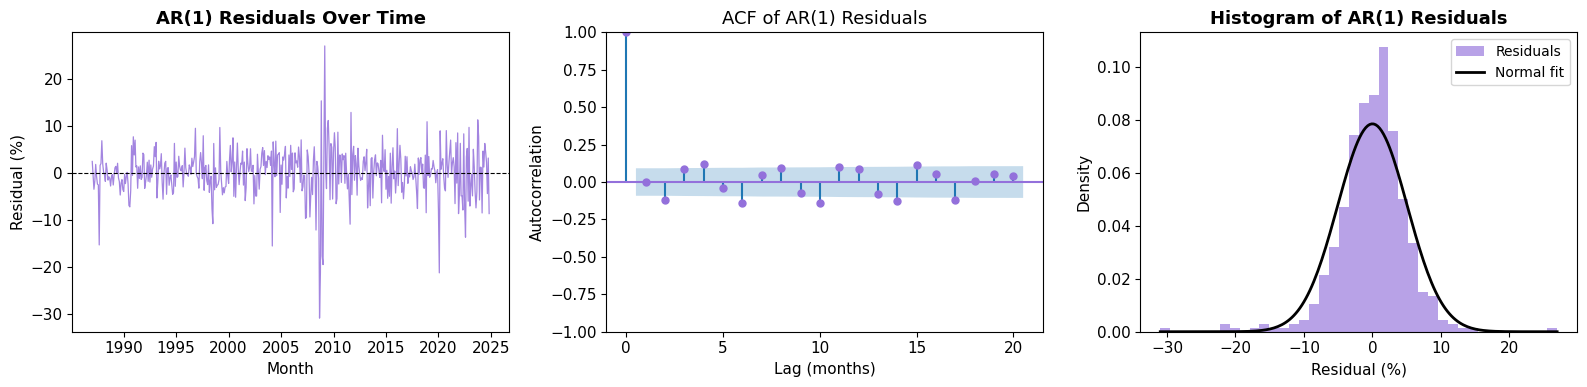

Chart saved: fig05_residual_diagnostics.png


In [12]:
# =============================================================================
# RESIDUAL DIAGNOSTICS — AR(1) model
# =============================================================================
from scipy.stats import norm as scipy_norm    # For normal curve overlay

# Re-define ar1_results and vwtret_series (cell independence)
vwtret_series = df_factors["vwtret"]
ar1_results   = AutoReg(vwtret_series, lags=1, old_names=False).fit()

ar1_residuals = ar1_results.resid   # The model residuals: actual return − predicted return

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Panel 1: Residuals over time ---
ax = axes[0]
ax.plot(ar1_residuals.index, ar1_residuals.values,
        color=COLOR_RESIDUAL, linewidth=0.9, alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("AR(1) Residuals Over Time", fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Residual (%)")

# --- Panel 2: ACF of residuals ---
ax = axes[1]
plot_acf(ar1_residuals, lags=20, ax=ax, color=COLOR_RESIDUAL, alpha=0.05, title="ACF of AR(1) Residuals")
ax.set_xlabel("Lag (months)")
ax.set_ylabel("Autocorrelation")

# --- Panel 3: Histogram with normal curve ---
ax = axes[2]
residual_mean = ar1_residuals.mean()
residual_std  = ar1_residuals.std()
ax.hist(ar1_residuals, bins=40, color=COLOR_RESIDUAL, alpha=0.65, density=True, label="Residuals")
x_range = np.linspace(ar1_residuals.min(), ar1_residuals.max(), 200)
normal_curve = scipy_norm.pdf(x_range, loc=residual_mean, scale=residual_std)
ax.plot(x_range, normal_curve, color="black", linewidth=2, label="Normal fit")
ax.set_title("Histogram of AR(1) Residuals", fontweight="bold")
ax.set_xlabel("Residual (%)")
ax.set_ylabel("Density")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(DEMOS_DIR / "fig05_residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: fig05_residual_diagnostics.png")

In [13]:
# =============================================================================
# LJUNG-BOX TEST — Formal test for residual autocorrelation
# =============================================================================
# H0: No autocorrelation in residuals at lags 1 through 10
# H1: At least one lag has significant autocorrelation

lb_test_result = acorr_ljungbox(ar1_residuals, lags=[5, 10, 15], return_df=True)

print("=" * 55)
print("Ljung-Box Test: Are AR(1) Residuals White Noise?")
print("=" * 55)
print("H0: No autocorrelation in residuals")
print()
print(lb_test_result.round(4).to_string())
print()

# Interpret each row
for lag_val, row in lb_test_result.iterrows():
    lb_stat = row["lb_stat"]
    lb_pval = row["lb_pvalue"]
    verdict = "PASS (no autocorrelation detected)" if lb_pval > 0.05 else "FAIL (autocorrelation detected)"
    print(f"  Lag {lag_val:2d}: stat = {lb_stat:.3f}, p = {lb_pval:.4f}  →  {verdict}")

Ljung-Box Test: Are AR(1) Residuals White Noise?
H0: No autocorrelation in residuals

    lb_stat  lb_pvalue
5   17.4648     0.0037
10  43.1327     0.0000
15  67.9570     0.0000

  Lag  5: stat = 17.465, p = 0.0037  →  FAIL (autocorrelation detected)
  Lag 10: stat = 43.133, p = 0.0000  →  FAIL (autocorrelation detected)
  Lag 15: stat = 67.957, p = 0.0000  →  FAIL (autocorrelation detected)


### Interpretation Checkpoint

> **Do the residuals look like white noise? What happens if they don't?**

**If the diagnostics pass (what you hope to see):**
- Residuals over time look like random scatter — no visible patterns or clustering
- ACF bars all stay within the blue confidence bands
- Ljung-Box p-values are all > 0.05 (fail to reject H₀ of no autocorrelation)
- Histogram is roughly bell-shaped

**If the diagnostics fail (what to do about it):**
- ACF still has significant spikes → add more lags (AR(2), AR(3)...)
- Residuals cluster in time (calm and volatile periods) → volatility clustering (ARCH/GARCH models handle this — beyond our scope)
- Residuals are not normal → use robust standard errors for inference

**REIT-specific note:** REIT returns often show **volatility clustering** — 2008, 2020 saw wildly elevated volatility. The histogram typically has heavier tails than a normal distribution (technically: **excess kurtosis**). This doesn't invalidate the AR model for point forecasting, but it does affect how we interpret confidence intervals.

---

## Section 8: 12-Month Forecast

The whole point of fitting a time series model is to **forecast the future**. Let's use the AR(1) model to generate a 12-month-ahead forecast for REIT returns.

### What does the forecast look like mathematically?

$$\hat{r}_{T+h} = \hat{\mu} + \hat{\phi}_1^h \cdot (r_T - \hat{\mu})$$

Because $|\hat{\phi}_1| < 1$, the term $\hat{\phi}_1^h$ shrinks toward zero as $h$ grows. This means:
- At short horizons (h=1), the forecast reflects recent returns
- At long horizons (h=12+), the forecast collapses toward the long-run mean

### Why do the confidence bands widen?

Each forecast step adds another layer of unpredictable shock $\varepsilon_{t+h}$. The further out we forecast, the more uncertainty accumulates. The bands represent how wide the range of plausible outcomes becomes.

In [14]:
# =============================================================================
# 12-MONTH AHEAD FORECAST WITH 95% CONFIDENCE INTERVALS
# =============================================================================

# Re-define everything (cell independence)
vwtret_series = df_factors["vwtret"]
ar1_results   = AutoReg(vwtret_series, lags=1, old_names=False).fit()

n_forecast_months = 12   # Forecast horizon

# Generate forecast: start from the end of the data (index = len(vwtret_series))
forecast_object = ar1_results.get_prediction(
    start=len(vwtret_series),
    end=len(vwtret_series) + n_forecast_months - 1,
    dynamic=True
)

# Extract the forecast values and confidence intervals
forecast_summary    = forecast_object.summary_frame(alpha=0.05)   # alpha=0.05 → 95% CI
forecast_values     = forecast_summary["mean"]                    # Point forecast
conf_int_lower      = forecast_summary["mean_ci_lower"]           # Lower bound of 95% CI
conf_int_upper      = forecast_summary["mean_ci_upper"]           # Upper bound of 95% CI

# Build forecast dates: monthly from the month after the last observed date
last_observed_date  = vwtret_series.index[-1]
forecast_dates      = pd.date_range(
    start=last_observed_date + pd.DateOffset(months=1),
    periods=n_forecast_months,
    freq="MS"   # Month Start frequency
)

# Assign dates to forecast outputs
forecast_values.index   = forecast_dates
conf_int_lower.index    = forecast_dates
conf_int_upper.index    = forecast_dates

print("=" * 55)
print("12-Month Forecast: REIT Value-Weighted Returns (%)")
print("=" * 55)
print(f"{'Month':<15} {'Forecast':>10} {'Lower 95%':>12} {'Upper 95%':>12}")
print("-" * 52)
for date_val, fcast, lo, hi in zip(forecast_dates, forecast_values, conf_int_lower, conf_int_upper):
    print(f"{date_val.strftime('%b %Y'):<15} {fcast:>10.3f} {lo:>12.3f} {hi:>12.3f}")

12-Month Forecast: REIT Value-Weighted Returns (%)
Month             Forecast    Lower 95%    Upper 95%
----------------------------------------------------
Dec 2024             0.546       -9.400       10.492
Jan 2025             0.796       -9.155       10.746
Feb 2025             0.803       -9.147       10.754
Mar 2025             0.803       -9.147       10.754
Apr 2025             0.803       -9.147       10.754
May 2025             0.803       -9.147       10.754
Jun 2025             0.803       -9.147       10.754
Jul 2025             0.803       -9.147       10.754
Aug 2025             0.803       -9.147       10.754
Sep 2025             0.803       -9.147       10.754
Oct 2025             0.803       -9.147       10.754
Nov 2025             0.803       -9.147       10.754


C:\Users\cas3526\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\cas3526\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


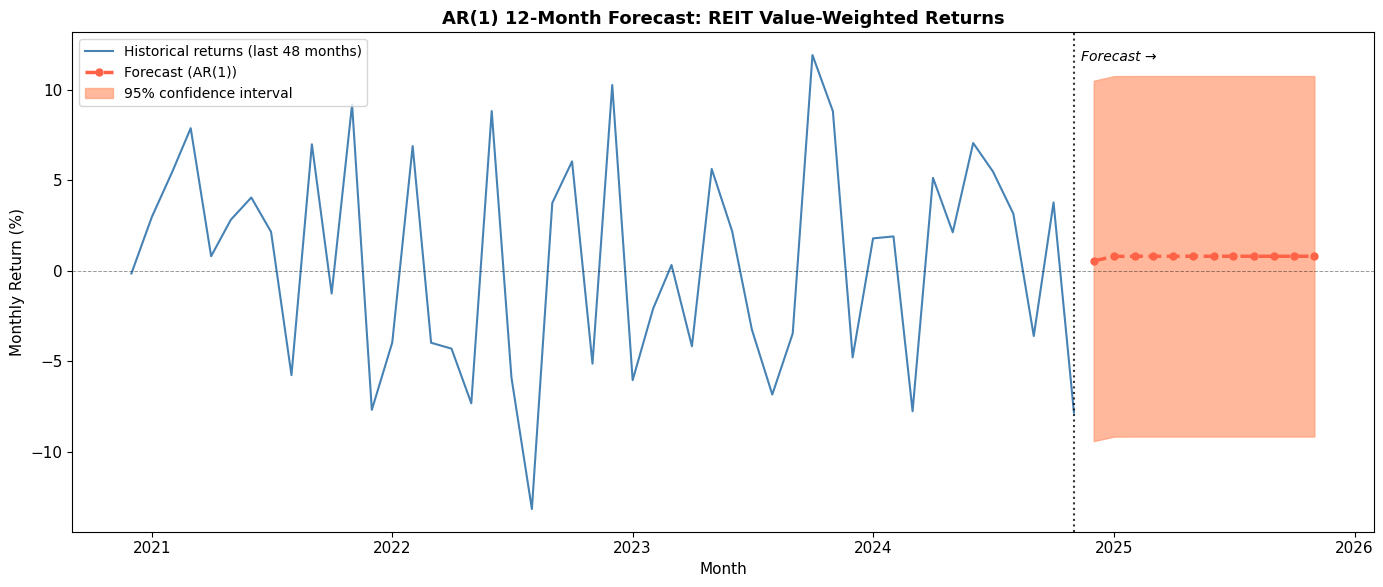

Chart saved: fig06_forecast.png

95% CI width at 1-month horizon:  19.89 percentage points
95% CI width at 12-month horizon: 19.90 percentage points
→ The uncertainty band is 1.0x wider at month 12 than month 1.


In [15]:
# =============================================================================
# CHART 6 — Forecast plot: last 48 months + 12-month ahead forecast
# =============================================================================

# Use the last 48 months of historical data as context
n_historical_months_to_show = 48
recent_returns = vwtret_series.iloc[-n_historical_months_to_show:]  # Last 48 months

fig, ax = plt.subplots(figsize=(14, 6))

# Historical returns (last 48 months)
ax.plot(recent_returns.index, recent_returns.values,
        color=COLOR_RETURNS, linewidth=1.5, label="Historical returns (last 48 months)")

# Forecast point estimates
ax.plot(forecast_dates, forecast_values.values,
        color=COLOR_FORECAST, linewidth=2.5, linestyle="--",
        marker="o", markersize=5, label="Forecast (AR(1))")

# Confidence interval shading
ax.fill_between(
    forecast_dates,
    conf_int_lower.values,
    conf_int_upper.values,
    color=COLOR_CI,
    alpha=0.75,
    label="95% confidence interval"
)

# Vertical dashed line separating historical from forecast
ax.axvline(x=last_observed_date, color="black", linewidth=1.5, linestyle=":", alpha=0.8)
ax.text(last_observed_date + pd.DateOffset(days=10),
        ax.get_ylim()[1] * 0.88,
        "Forecast →",
        fontsize=10, color="black", fontstyle="italic")

# Zero line for reference
ax.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.4)

ax.set_title("AR(1) 12-Month Forecast: REIT Value-Weighted Returns", fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly Return (%)")
ax.legend(fontsize=10, loc="upper left")
plt.tight_layout()
plt.savefig(DEMOS_DIR / "fig06_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: fig06_forecast.png")

# Measure how wide the bands are at the end of the horizon
ci_width_month1  = conf_int_upper.iloc[0]  - conf_int_lower.iloc[0]
ci_width_month12 = conf_int_upper.iloc[-1] - conf_int_lower.iloc[-1]
print(f"\n95% CI width at 1-month horizon:  {ci_width_month1:.2f} percentage points")
print(f"95% CI width at 12-month horizon: {ci_width_month12:.2f} percentage points")
print(f"→ The uncertainty band is {ci_width_month12 / ci_width_month1:.1f}x wider at month 12 than month 1.")

### Interpretation Checkpoint

> **Why do the confidence bands widen? What does it mean for a 12-month-ahead forecast to be very uncertain?**

Each forecast step compounds the unpredictability from the previous one. After 12 months, the possible outcomes span a very wide range — the model might reasonably predict anything from a substantial loss to a substantial gain.

**Teaching note on AR(1) near zero:**  
If $\hat{\phi}_1$ is small (close to zero), the forecast rapidly converges to the long-run mean — the dotted forecast line may appear nearly flat after just a few months. This is **mathematically correct** for a near-random-walk return series. It means: *the best forecast for next month is approximately the historical average*, and the AR(1) model is not much better than a simple "predict the mean" rule. That is an important, honest insight, not a bug.

**Bottom line:** For a well-diversified REIT index, the AR(1) forecasts the *direction* of returns with very limited accuracy. The confidence intervals are so wide that they include both gains and losses at essentially every horizon beyond 1–2 months.

---

## Section 9: What Can We Actually Forecast? — An Honest Assessment

This is the most important section of the demo. Take your time with it.

### REIT Returns Are Hard to Forecast

The AR(1) model we estimated has a very small lag coefficient ($\hat{\phi}_1$ is likely around 0.05–0.15). That number is the fraction of last month's return that "carries over" into this month. An R² of 1–3% is typical.

**What this means:** Our model explains about 1–3% of the variation in monthly REIT returns. The remaining 97–99% is noise.

### Why Are Returns Hard to Forecast?

If REIT returns were reliably predictable, sophisticated investors would immediately exploit that predictability. If every investor knows that "returns are high in January," they all buy in December, driving prices up until the January premium disappears. This logic — the **Efficient Markets Hypothesis** — suggests that asset returns should be close to unpredictable in liquid markets.

REIT returns have *some* predictability (the lag-1 autocorrelation is nonzero) because of **appraisal smoothing**: the underlying real estate assets are appraised quarterly or annually, not continuously, so NAV (net asset value) adjustments lag the market. That creates artificial momentum in the return series.

### The Price Level vs. Return Paradox

Here is a paradox that trips up even professional analysts:

> *"If I fit a model to the price level, I get a very high R². Doesn't that mean the model is great?"*

**No.** The price level is non-stationary (a random walk). A model that says "tomorrow's price ≈ today's price" will have a very high in-sample R² — but it is trivially predicting that today is similar to today. Out of sample, such models fail completely.

The right way to judge a return forecasting model is **out-of-sample predictive accuracy** — how well does it predict returns in a new period it was not trained on? For REIT aggregate returns, the answer is: not very well.

### What *Can* We Forecast?

- **Volatility** (squared returns, ARCH/GARCH models) is more predictable than direction — calm periods tend to be followed by calm periods
- **Long-run fundamentals** (cap rates, dividend yields) predict returns over 3–5 year horizons with modest accuracy
- **Individual REIT cross-sectional returns** can be partially predicted using firm-level characteristics (the subject of Weeks 10–11!)

Time series AR forecasting is most valuable for **macro series** (GDP, inflation, interest rates) where structural forces create longer-run persistence.

---

## Section 10: Factor Autocorrelation Comparison — REIT Returns vs. Momentum

Not all return series have the same autocorrelation structure. Let's compare our near-random REIT returns with the **momentum factor** (`mom_long`).

The **momentum factor** is constructed by going long stocks with the highest recent returns and short stocks with the lowest. By construction, it captures persistence — so we would expect its autocorrelation structure to be noticeably different from REIT returns.

This comparison drives home the key point: autocorrelation is not just a theoretical concept — it varies meaningfully across assets and strategies.

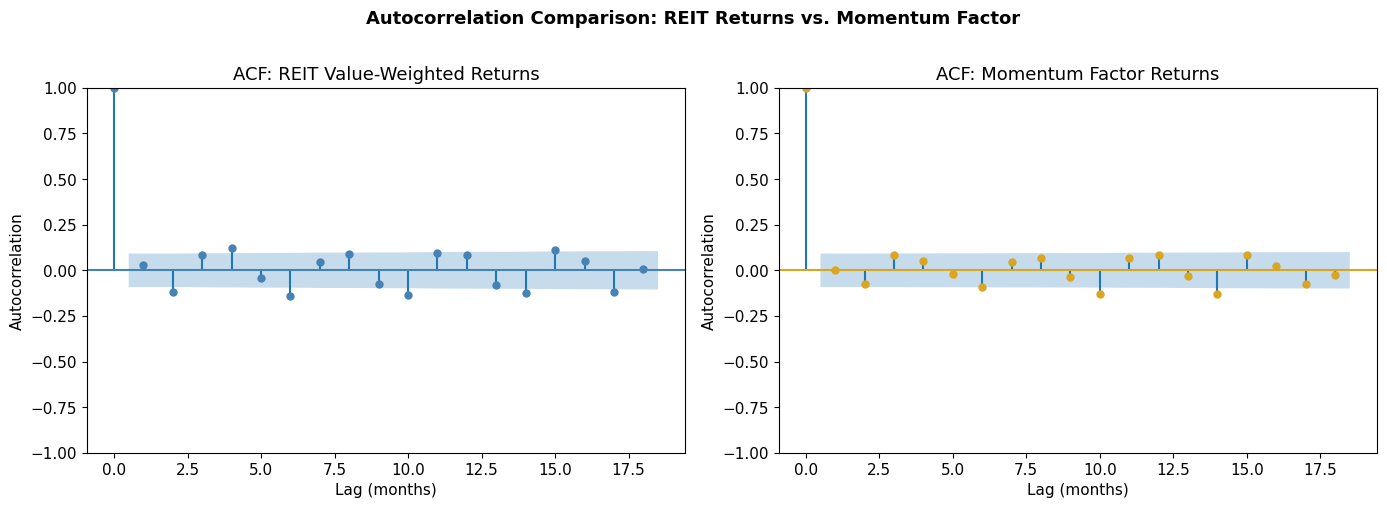

Chart saved: fig07_acf_comparison.png

Lag        REIT Returns ACF     Momentum ACF
--------------------------------------------
1                    0.0296           0.0030
2                   -0.1187          -0.0746
3                    0.0854           0.0832


In [16]:
# =============================================================================
# CHART 7 — ACF comparison: REIT returns vs. momentum factor
# =============================================================================

# Re-define both series (cell independence)
vwtret_series = df_factors["vwtret"].dropna()
mom_series    = df_factors["mom_long"].dropna()   # Momentum factor monthly return (%)

# Align to the same date range (intersection of both series)
common_dates  = vwtret_series.index.intersection(mom_series.index)
vwtret_aligned = vwtret_series.loc[common_dates]
mom_aligned    = mom_series.loc[common_dates]

n_lags_compare = 18   # 18 months of lags

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: ACF of REIT returns ---
plot_acf(
    vwtret_aligned,
    lags=n_lags_compare,
    ax=axes[0],
    color=COLOR_RETURNS,
    alpha=0.05,
    title="ACF: REIT Value-Weighted Returns"
)
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Autocorrelation")

# --- Right: ACF of momentum factor ---
plot_acf(
    mom_aligned,
    lags=n_lags_compare,
    ax=axes[1],
    color=COLOR_MOMENTUM,
    alpha=0.05,
    title="ACF: Momentum Factor Returns"
)
axes[1].set_xlabel("Lag (months)")
axes[1].set_ylabel("Autocorrelation")

fig.suptitle("Autocorrelation Comparison: REIT Returns vs. Momentum Factor",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(DEMOS_DIR / "fig07_acf_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: fig07_acf_comparison.png")

# Print summary stats for both series
from statsmodels.tsa.stattools import acf as compute_acf
acf_vwt = compute_acf(vwtret_aligned, nlags=3, fft=True)
acf_mom = compute_acf(mom_aligned,    nlags=3, fft=True)

print()
print(f"{'Lag':<8} {'REIT Returns ACF':>18} {'Momentum ACF':>16}")
print("-" * 44)
for lag_num in range(1, 4):
    print(f"{lag_num:<8} {acf_vwt[lag_num]:>18.4f} {acf_mom[lag_num]:>16.4f}")

### What Do You Notice?

Compare the two ACF plots:

- **REIT returns:** Mostly within the confidence bands. The lag-1 autocorrelation may be marginally significant, but autocorrelation decays quickly.
- **Momentum factor:** Typically shows stronger autocorrelation at multiple lags. By construction, momentum strategies rely on persistence — winners keep winning for several months. That persistence shows up directly in the ACF.

**Key takeaway:** The *degree* of autocorrelation is not fixed — it depends on the economic mechanism driving the returns. Time series modeling must start with understanding *why* autocorrelation exists or does not exist.

---

## Section 11: Summary and Key Takeaways

Let's put everything together.

### What We Covered

1. **Time series data is not independent.** Observations are correlated across time — modeling them as if they were independent (like a cross-section) is wrong.

2. **Stationarity is the foundation.** Before fitting any model, always check whether the series is stationary. Work with returns (or first differences), not price levels.

3. **The ADF test formalizes the visual check.** For REIT returns: stationary (p ≈ 0). For the price index: non-stationary (p large). The same underlying data behaves completely differently depending on transformation.

4. **ACF and PACF reveal the autocorrelation structure.** Use them to diagnose the series and choose the AR lag order. For REIT returns, autocorrelation is mild — consistent with near-random-walk behavior.

5. **AR(1) is a reasonable model for REIT returns.** It captures the mild lag-1 persistence from appraisal smoothing. AIC/BIC typically confirm AR(1) as the optimal lag order.

6. **Residual diagnostics are mandatory.** After fitting the model, check that residuals look like white noise. If they don't, the model needs refinement.

7. **Confidence bands should be wide — that is honest.** For a near-random series, 12-month-ahead forecasts are highly uncertain. Narrow confidence bands on a hard-to-forecast series would be misleading.

8. **Autocorrelation varies across assets.** Momentum returns have stronger autocorrelation than REIT returns — reflecting the economic mechanism behind each strategy.

---

### Connection to Assignment 12

In **Assignment 12**, you will apply exactly these steps to the same `factors_master_long_only.csv` dataset:

- Parse dates, build a DatetimeIndex, drop NaN rows
- Plot and inspect the return series
- Run the ADF test on at least two series
- Plot ACF and PACF
- Fit AR(1) and AR(2) models and compare AIC/BIC
- Run residual diagnostics
- Generate a forecast and interpret the confidence intervals

The code in this demo is your direct reference — you can adapt it cell by cell.

---

### One Final Thought

The honest message of this week is that **financial returns are hard to forecast**. This is not a failure of statistics — it is a feature of competitive markets. When you hear confident short-term market predictions in the financial media, remember the AR(1) forecast you built today: wide confidence bands, near-flat point forecast, R² under 5%. Hold those confident predictions to a higher standard.